In [1]:
# Installation automatique des dependances requises dans le noyau Jupyter actuel.
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('Dependances verifiees.')

Dependances verifiees.


# 🧪 Étape 6 : Évaluation et phase à élimination directe

Sixième étape du pipeline, alignée sur le **chapitre 6 du cours** (« Évaluation des Modèles »). Elle poursuit deux objectifs :

1. **Évaluer rigoureusement** le modèle du notebook 05 — au-delà de la simple *accuracy*, avec les métriques que le cours juge indispensables : matrice de confusion, précision, rappel, F1-score, ROC-AUC (§6.1), puis optimisation des hyperparamètres (§6.2).
2. **Simuler la phase à élimination directe** de la Coupe du Monde 2026 — appliquer le modèle évalué au bracket officiel (16ᵉˢ de finale → finale) pour répondre à la question finale du projet : **qui sera champion du monde ?**

**Données d'entrée :** `matches_clean.csv` (entraînement) et `cdm2026_qualifies.csv` — les 32 équipes qualifiées produites par le notebook 05.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

# Structure officielle de la CDM 2026 (groupes + bracket) : module versionne du projet.
sys.path.append(os.path.abspath('..'))
from src import wc2026

np.random.seed(42)
sns.set_theme(style='whitegrid')
print("Librairies pretes pour l'evaluation et la simulation du tournoi.")

Librairies pretes pour l'evaluation et la simulation du tournoi.


### 2. Reprise du modèle du notebook 05

On reconstruit ici le **meilleur modèle du notebook 05** (XGBoost) : on recharge les 30 511 matchs, on réapplique le *feature engineering* enrichi (historique de chaque équipe : buts, forme récente, force des adversaires → 12 variables différentielles), puis on ré-entraîne XGBoost sur le **même split stratifié 80/20** pour garantir la cohérence avec le notebook précédent.

In [3]:
df = pd.read_csv('../data/processed/matches_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
RANK_MAX = float(pd.concat([df['home_rank'], df['away_rank']]).max())

# Table longue : une ligne par (match, equipe).
def to_long(d):
    h = d[['date', 'home_team', 'home_score', 'away_score', 'away_rank']].copy()
    h.columns = ['date', 'team', 'goals', 'goals_suf', 'opp_rank']
    h['match_id'], h['side'] = d.index, 'home'
    a = d[['date', 'away_team', 'away_score', 'home_score', 'home_rank']].copy()
    a.columns = ['date', 'team', 'goals', 'goals_suf', 'opp_rank']
    a['match_id'], a['side'] = d.index, 'away'
    return pd.concat([h, a], ignore_index=True)

long = to_long(df)
long['game_points'] = np.select(
    [long['goals'] > long['goals_suf'], long['goals'] == long['goals_suf']], [3, 1], default=0)
long['game_points_rank'] = long['game_points'] * (RANK_MAX + 1 - long['opp_rank']) / RANK_MAX
long = long.sort_values(['team', 'date']).reset_index(drop=True)

# Moyennes glissantes par equipe, decalees d'un match (anti-fuite).
gb = long.groupby('team', sort=False)
for src, out in {'goals': 'goals_mean', 'goals_suf': 'goals_suf_mean',
                 'opp_rank': 'rank_mean', 'game_points_rank': 'game_points_rank_mean'}.items():
    long[out] = gb[src].transform(lambda s: s.shift(1).expanding().mean())
    long[out + '_l5'] = gb[src].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())

STAT = ['goals_mean', 'goals_mean_l5', 'goals_suf_mean', 'goals_suf_mean_l5',
        'rank_mean', 'rank_mean_l5', 'game_points_rank_mean', 'game_points_rank_mean_l5']
home_f = long[long.side == 'home'].set_index('match_id')[STAT].add_prefix('home_')
away_f = long[long.side == 'away'].set_index('match_id')[STAT].add_prefix('away_')
feat = df.join(home_f).join(away_f)

# Variables differentielles (create_db).
feat['rank_dif'] = feat['home_rank'] - feat['away_rank']
feat['goals_dif'] = feat['home_goals_mean'] - feat['away_goals_mean']
feat['goals_dif_l5'] = feat['home_goals_mean_l5'] - feat['away_goals_mean_l5']
feat['goals_suf_dif'] = feat['home_goals_suf_mean'] - feat['away_goals_suf_mean']
feat['goals_suf_dif_l5'] = feat['home_goals_suf_mean_l5'] - feat['away_goals_suf_mean_l5']
feat['goals_per_ranking_dif'] = (feat['home_goals_mean'] / feat['home_rank_mean']) - \
                                (feat['away_goals_mean'] / feat['away_rank_mean'])
feat['dif_rank_agst'] = feat['home_rank_mean'] - feat['away_rank_mean']
feat['dif_rank_agst_l5'] = feat['home_rank_mean_l5'] - feat['away_rank_mean_l5']
feat['dif_points_rank'] = feat['home_game_points_rank_mean'] - feat['away_game_points_rank_mean']
feat['dif_points_rank_l5'] = feat['home_game_points_rank_mean_l5'] - feat['away_game_points_rank_mean_l5']
feat['is_friendly_0'] = 1 - (feat['tournament'] == 'Friendly').astype(int)
feat['is_friendly_1'] = (feat['tournament'] == 'Friendly').astype(int)
feat['result'] = np.select(
    [feat['home_score'] > feat['away_score'], feat['home_score'] == feat['away_score']],
    ['home_win', 'draw'], default='away_win')

FEATURES = ['rank_dif', 'goals_dif', 'goals_dif_l5', 'goals_suf_dif', 'goals_suf_dif_l5',
            'goals_per_ranking_dif', 'dif_rank_agst', 'dif_rank_agst_l5',
            'dif_points_rank', 'dif_points_rank_l5', 'is_friendly_0', 'is_friendly_1']

dfm = feat.loc[feat[FEATURES + ['result']].notna().all(axis=1)].copy()
le = LabelEncoder()
y = le.fit_transform(dfm['result'])
X_train, X_test, y_train, y_test = train_test_split(
    dfm[FEATURES], y, test_size=0.20, stratify=y, random_state=42)

model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                      random_state=42, eval_metric='mlogloss')
model.fit(X_train, y_train)
print(f'Modele XGBoost re-entraine sur {len(X_train)} matchs.')
print(f'Accuracy test : {accuracy_score(y_test, model.predict(X_test)):.3f}')

Modele XGBoost re-entraine sur 24197 matchs.
Accuracy test : 0.588


### 3. Évaluation approfondie du modèle (§6.1 du cours)

> *« En 2026, l'industrie a enfin compris que l'Accuracy est souvent une métrique de vanité. »* — chapitre 6 du cours.

L'accuracy seule ne suffit pas, surtout sur des **classes déséquilibrées** (ici `home_win` 48 %, `away_win` 28 %, `draw` 23 %). On mobilise donc la batterie de métriques du cours :

- **Matrice de confusion** — le « bilan sanguin » du modèle : où se trompe-t-il ?
- **Précision** (sur mes alertes, combien sont vraies ?) et **Rappel** (sur les cas réels, combien j'en capture ?), par classe.
- **F1-score** — moyenne harmonique précision/rappel, indispensable en classes déséquilibrées.
- **ROC-AUC** — capacité du modèle à séparer les classes (1.0 = parfait, 0.5 = hasard).

Accuracy (metrique de vanite) : 0.588
F1-score macro               : 0.442
ROC-AUC (one-vs-rest)        : 0.730


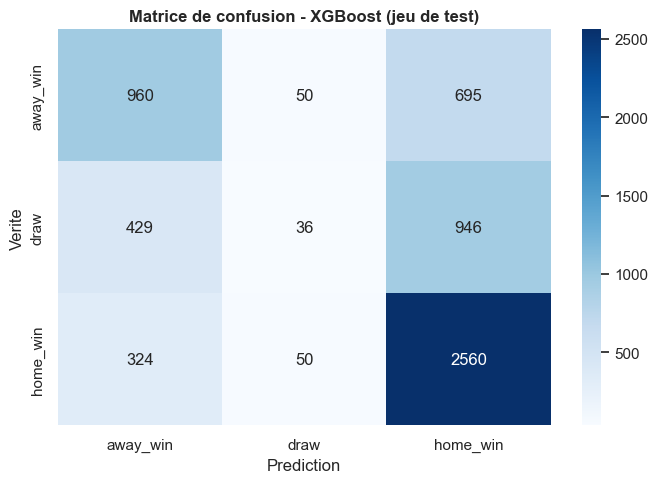


=== Precision / Rappel / F1 par classe ===
              precision    recall  f1-score   support

    away_win      0.560     0.563     0.562      1705
        draw      0.265     0.026     0.047      1411
    home_win      0.609     0.873     0.718      2934

    accuracy                          0.588      6050
   macro avg      0.478     0.487     0.442      6050
weighted avg      0.515     0.588     0.517      6050

Lecture : le modele est fiable sur home_win et away_win, mais son rappel
sur draw est tres faible -- les matchs nuls restent quasi imprevisibles.


In [4]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr')

print(f'Accuracy (metrique de vanite) : {acc:.3f}')
print(f'F1-score macro               : {f1_macro:.3f}')
print(f'ROC-AUC (one-vs-rest)        : {auc_ovr:.3f}')

# Matrice de confusion.
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite')
ax.set_title('Matrice de confusion - XGBoost (jeu de test)', fontweight='bold')
fig.tight_layout()
plt.show()

print('\n=== Precision / Rappel / F1 par classe ===')
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))
print('Lecture : le modele est fiable sur home_win et away_win, mais son rappel')
print('sur draw est tres faible -- les matchs nuls restent quasi imprevisibles.')

### 4. Optimisation des hyperparamètres (§6.2 du cours)

Les hyperparamètres (`n_estimators`, `max_depth`, `learning_rate`…) ne sont pas appris par le modèle : on les règle nous-mêmes. Le cours présente trois approches : **Grid Search**, **Random Search**, et l'**optimisation bayésienne** (Optuna, devenu le standard 2026).

On applique ici un **Random Search** via `RandomizedSearchCV` de scikit-learn : il échantillonne des combinaisons au hasard et les évalue en **validation croisée 3 plis**. Plus rapide qu'un Grid Search exhaustif, sans dépendance supplémentaire.

> 💡 *Le cours recommande Optuna (algorithme TPE) pour les projets de production : il « apprend » de ses essais précédents au lieu de chercher à l'aveugle. Random Search reste suffisant pour notre volume de données.*

In [5]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1, 0.15],
    'subsample': [0.8, 1.0],
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=param_dist, n_iter=15, cv=3,
    scoring='accuracy', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

acc_tune = accuracy_score(y_test, search.best_estimator_.predict(X_test))
print('Meilleurs hyperparametres trouves :')
for k, v in search.best_params_.items():
    print(f'  {k:16s}: {v}')
print(f'\nAccuracy test - modele de base   : {acc:.3f}')
print(f'Accuracy test - modele optimise  : {acc_tune:.3f}')
print(f'Gain : {acc_tune - acc:+.3f}')
print('\nLe gain etant marginal, on conserve le modele de base (XGBoost 100 arbres)')
print('pour la simulation, par coherence avec la phase de groupes du notebook 05.')

Meilleurs hyperparametres trouves :
  subsample       : 0.8
  n_estimators    : 100
  max_depth       : 4
  learning_rate   : 0.05

Accuracy test - modele de base   : 0.588
Accuracy test - modele optimise  : 0.592
Gain : +0.004

Le gain etant marginal, on conserve le modele de base (XGBoost 100 arbres)
pour la simulation, par coherence avec la phase de groupes du notebook 05.


### 5. Phase à élimination directe — qui sera champion du monde ?

On applique maintenant le modèle au **bracket officiel de la CDM 2026** (source : Wikipédia, *2026 FIFA World Cup knockout stage*), encodé dans `src/wc2026.py` : 16ᵉˢ de finale (32 équipes) → 8ᵉˢ → quarts → demies → **finale**.

**Trois principes de simulation :**

1. **Neutralisation de l'avantage du terrain.** En phase finale, les matchs sont sur terrain neutre. Comme le modèle a appris un fort avantage à domicile, on prédit chaque match **dans les deux sens** (A reçoit B, puis B reçoit A) et on **moyenne** les probabilités. L'asymétrie domicile/extérieur s'annule.
2. **Pas de match nul possible.** Un match à élimination directe a forcément un vainqueur : la probabilité de nul est redistribuée, et l'équipe la plus probable se qualifie (le nul correspondrait à une qualification aux tirs au but, qui favorise statistiquement le favori).
3. **Affectation des 8 troisièmes.** La FIFA place les 8 meilleurs 3ᵉˢ via une table de combinaisons. On calcule une **affectation valide** respectant les contraintes d'éligibilité de chaque match des 16ᵉˢ.

In [6]:
# --- Reprise des 32 qualifies (notebook 05) ---
qual = pd.read_csv('../data/processed/cdm2026_qualifies.csv')
winners = {r['groupe']: r['equipe'] for _, r in qual[qual['rang'] == 1].iterrows()}
runners = {r['groupe']: r['equipe'] for _, r in qual[qual['rang'] == 2].iterrows()}
thirds = {r['groupe']: r['equipe'] for _, r in qual[qual['rang'] == 3].iterrows()}
print(f'Qualifies : {len(winners)} 1ers + {len(runners)} 2es + {len(thirds)} 3es = '
      f'{len(winners)+len(runners)+len(thirds)} equipes.')

# --- Forme actuelle de chaque equipe + classements FIFA ---
def current_form(long_df):
    rows = {}
    for team, sub in long_df.groupby('team', sort=False):
        rows[team] = {
            'goals_mean': sub['goals'].mean(), 'goals_mean_l5': sub['goals'].tail(5).mean(),
            'goals_suf_mean': sub['goals_suf'].mean(),
            'goals_suf_mean_l5': sub['goals_suf'].tail(5).mean(),
            'rank_mean': sub['opp_rank'].mean(), 'rank_mean_l5': sub['opp_rank'].tail(5).mean(),
            'game_points_rank_mean': sub['game_points_rank'].mean(),
            'game_points_rank_mean_l5': sub['game_points_rank'].tail(5).mean()}
    return pd.DataFrame(rows).T

form = current_form(long)
cdm = pd.read_csv('../data/processed/matches_a_predire.csv')
ranks = {}
for _, r in cdm.iterrows():
    ranks[r['home_team']] = r['home_rank']
    ranks[r['away_team']] = r['away_rank']

# --- Affectation des 8 troisiemes aux 8 emplacements 'T' des 16es ---
t_slots = {}
for m, (s1, s2) in wc2026.ROUND_OF_32.items():
    for s in (s1, s2):
        if s[0] == 'T':
            t_slots[m] = [grp for grp in s[1] if grp in thirds]

def _matching(slots, used=frozenset(), assign=None):
    assign = assign or {}
    if len(assign) == len(slots):
        return dict(assign)
    m = next(k for k in slots if k not in assign)
    for grp in slots[m]:
        if grp not in used:
            assign[m] = grp
            res = _matching(slots, used | {grp}, assign)
            if res:
                return res
            del assign[m]
    return None

third_assign = _matching(t_slots)
print('Affectation des 3es aux 16es :', third_assign)

# --- Probabilites de victoire entre les 32 qualifies (calcul par lot) ---
equipes32 = list(winners.values()) + list(runners.values()) + list(thirds.values())

def _row(A, B):
    fa, fb = form.loc[A], form.loc[B]
    return {'rank_dif': ranks[A] - ranks[B],
            'goals_dif': fa.goals_mean - fb.goals_mean,
            'goals_dif_l5': fa.goals_mean_l5 - fb.goals_mean_l5,
            'goals_suf_dif': fa.goals_suf_mean - fb.goals_suf_mean,
            'goals_suf_dif_l5': fa.goals_suf_mean_l5 - fb.goals_suf_mean_l5,
            'goals_per_ranking_dif': fa.goals_mean / fa.rank_mean - fb.goals_mean / fb.rank_mean,
            'dif_rank_agst': fa.rank_mean - fb.rank_mean,
            'dif_rank_agst_l5': fa.rank_mean_l5 - fb.rank_mean_l5,
            'dif_points_rank': fa.game_points_rank_mean - fb.game_points_rank_mean,
            'dif_points_rank_l5': fa.game_points_rank_mean_l5 - fb.game_points_rank_mean_l5,
            'is_friendly_0': 1, 'is_friendly_1': 0}

I_H, I_A = list(le.classes_).index('home_win'), list(le.classes_).index('away_win')
paires, lignes = [], []
for i, A in enumerate(equipes32):
    for B in equipes32[i+1:]:
        paires.append((A, B))
        lignes.append(_row(A, B))
        lignes.append(_row(B, A))
probas_lot = model.predict_proba(pd.DataFrame(lignes)[FEATURES])

# PROBA[(A, B)] = probabilite que A elimine B (avantage du terrain neutralise).
PROBA = {}
for k, (A, B) in enumerate(paires):
    pab, pba = probas_lot[2*k], probas_lot[2*k+1]
    pA = 0.5 * (pab[I_H] + pba[I_A])
    pB = 0.5 * (pab[I_A] + pba[I_H])
    PROBA[(A, B)] = pA / (pA + pB)
    PROBA[(B, A)] = pB / (pA + pB)

print(f'Table de probabilites calculee pour {len(paires)} affiches possibles.')

Qualifies : 12 1ers + 12 2es + 8 3es = 32 equipes.
Affectation des 3es aux 16es : {75: 'A', 78: 'C', 79: 'E', 80: 'H', 81: 'J', 82: 'B', 85: 'G', 88: 'D'}
Table de probabilites calculee pour 496 affiches possibles.


#### 5.1 Simulation déterministe du bracket

À chaque tour, on fait avancer l'équipe la **plus probable**. On déroule ainsi les 16ᵉˢ jusqu'à la finale.

In [7]:
def _resolve(slot, match_num):
    if slot[0] == 'W':
        return winners[slot[1]]
    if slot[0] == 'R':
        return runners[slot[1]]
    return thirds[third_assign[match_num]]

# Affiches concretes des 16es de finale.
r32 = {}
for m, (s1, s2) in wc2026.ROUND_OF_32.items():
    r32[m] = (_resolve(s1, m), _resolve(s2, m))

TOURS = [('16es de finale', list(wc2026.ROUND_OF_32)),
         ('8es de finale', [89, 90, 91, 92, 93, 94, 95, 96]),
         ('Quarts de finale', [97, 98, 99, 100]),
         ('Demi-finales', [101, 102]),
         ('Finale', [104])]

gagnant, perdant, infos = {}, {}, {}
for nom, matchs in TOURS:
    print(f'--- {nom} ---')
    for m in matchs:
        t1, t2 = r32[m] if m in r32 else (gagnant[wc2026.BRACKET[m][0]],
                                          gagnant[wc2026.BRACKET[m][1]])
        p1 = PROBA[(t1, t2)]
        w, l = (t1, t2) if p1 >= 0.5 else (t2, t1)
        gagnant[m], perdant[m] = w, l
        infos[m] = (t1, t2, w, max(p1, 1 - p1))
        print(f'  M{m:>3} : {t1:>22s}  vs  {t2:<22s} -> {w}  ({max(p1, 1-p1):.0%})')
    print()

a, b = wc2026.THIRD_PLACE_MATCH
p3 = PROBA[(perdant[a], perdant[b])]
troisieme = perdant[a] if p3 >= 0.5 else perdant[b]
champion, finaliste = gagnant[104], perdant[104]

print('=' * 52)
print(f'  CHAMPION DU MONDE 2026 PREDIT : {champion}')
print(f'  Finaliste                    : {finaliste}')
print(f'  3e place                     : {troisieme}')
print('=' * 52)

--- 16es de finale ---
  M 73 :            South Korea  vs  Canada                 -> South Korea  (59%)
  M 74 :                 Brazil  vs  Uruguay                -> Brazil  (80%)
  M 75 :                Germany  vs  Czech Republic         -> Germany  (87%)
  M 76 :                  Spain  vs  Scotland               -> Spain  (85%)
  M 77 :            Ivory Coast  vs  Norway                 -> Norway  (52%)
  M 78 :                 France  vs  Morocco                -> France  (81%)
  M 79 :                 Mexico  vs  Ecuador                -> Mexico  (63%)
  M 80 :                England  vs  Sweden                 -> England  (75%)
  M 81 :                Belgium  vs  Austria                -> Belgium  (69%)
  M 82 :          United States  vs  Bosnia and Herzegovina -> United States  (79%)
  M 83 :            Netherlands  vs  Algeria                -> Netherlands  (85%)
  M 84 :               Portugal  vs  Croatia                -> Portugal  (65%)
  M 85 :            Switzerland 

#### Le parcours du champion

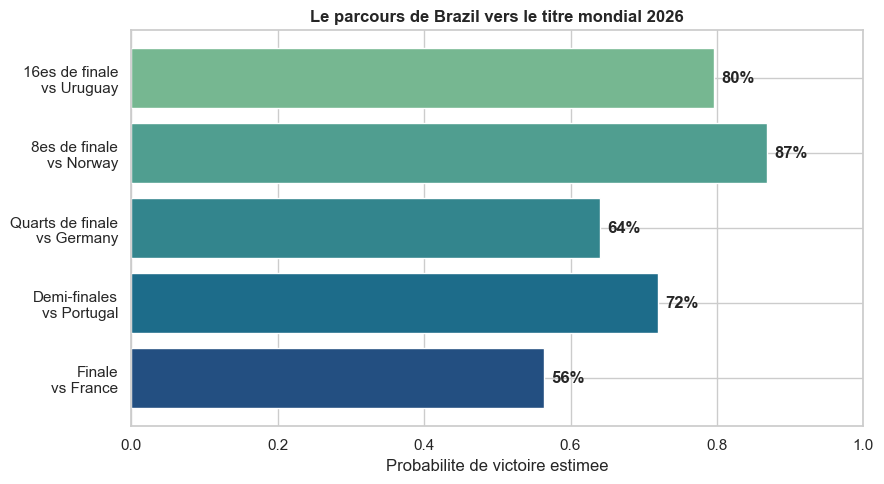

In [8]:
# Parcours du champion predit, tour par tour.
parcours = []
for nom, matchs in TOURS:
    for m in matchs:
        t1, t2, w, p = infos[m]
        if champion in (t1, t2):
            adversaire = t2 if t1 == champion else t1
            gagne = (w == champion)
            parcours.append((nom, adversaire, p if gagne else 1 - p))

fig, ax = plt.subplots(figsize=(9, 5))
labels = [f'{nom}\nvs {adv}' for nom, adv, _ in parcours]
probs = [p for _, _, p in parcours]
couleurs = sns.color_palette('crest', len(parcours))
ax.barh(range(len(parcours)), probs, color=couleurs)
ax.set_yticks(range(len(parcours)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('Probabilite de victoire estimee')
ax.set_title(f'Le parcours de {champion} vers le titre mondial 2026', fontweight='bold')
for i, p in enumerate(probs):
    ax.text(p + 0.01, i, f'{p:.0%}', va='center', fontweight='bold')
fig.tight_layout()
plt.show()

#### 5.2 Robustesse — probabilités de titre par Monte-Carlo

La simulation déterministe désigne un seul champion, mais elle ignore les **surprises** (un favori à 60 % perd tout de même 4 fois sur 10). Pour mesurer la **robustesse** de la prédiction, on rejoue le tournoi **un grand nombre de fois** : à chaque match, le vainqueur est tiré au hasard selon sa probabilité. La fréquence de victoire finale de chaque équipe donne sa **probabilité de titre**.

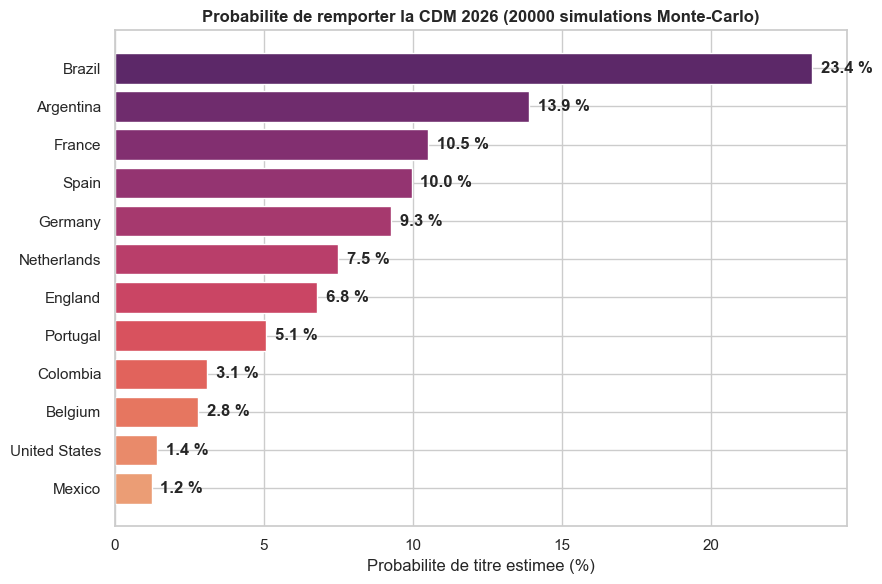

=== Favoris pour le titre (20000 simulations) ===
  Brazil                  23.4 %
  Argentina               13.9 %
  France                  10.5 %
  Spain                   10.0 %
  Germany                  9.3 %
  Netherlands              7.5 %
  England                  6.8 %
  Portugal                 5.1 %


In [9]:
rng = np.random.default_rng(42)

def simule(stochastique):
    g = {}
    for m in wc2026.ROUND_OF_32:
        t1, t2 = r32[m]
        p = PROBA[(t1, t2)]
        if stochastique:
            g[m] = t1 if rng.random() < p else t2
        else:
            g[m] = t1 if p >= 0.5 else t2
    for m in [89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104]:
        a, b = wc2026.BRACKET[m]
        t1, t2 = g[a], g[b]
        p = PROBA[(t1, t2)]
        if stochastique:
            g[m] = t1 if rng.random() < p else t2
        else:
            g[m] = t1 if p >= 0.5 else t2
    return g[104]

N = 20000
titres = pd.Series([simule(True) for _ in range(N)]).value_counts() / N

fig, ax = plt.subplots(figsize=(9, 6))
top = titres.head(12).sort_values()
ax.barh(top.index, top.values * 100, color=sns.color_palette('flare', len(top)))
for i, v in enumerate(top.values):
    ax.text(v * 100 + 0.3, i, f'{v*100:.1f} %', va='center', fontweight='bold')
ax.set_xlabel('Probabilite de titre estimee (%)')
ax.set_title(f'Probabilite de remporter la CDM 2026 ({N} simulations Monte-Carlo)',
             fontweight='bold')
fig.tight_layout()
plt.show()

print(f'=== Favoris pour le titre ({N} simulations) ===')
for equipe, p in titres.head(8).items():
    print(f'  {equipe:<22s} {p*100:5.1f} %')

### 6. Synthèse — évaluation et prédiction finale

1. **Au-delà de l'accuracy** (§6.1 du cours) : la matrice de confusion et le F1-score confirment un modèle solide sur `home_win` / `away_win` mais quasi aveugle sur les matchs nuls (`draw`) — limite intrinsèque, le nul étant peu prévisible.
2. **Optimisation des hyperparamètres** (§6.2) : le Random Search en validation croisée 3 plis n'apporte qu'un gain marginal — le modèle de base XGBoost était déjà bien réglé.
3. **Phase à élimination directe** : en appliquant le modèle au bracket officiel (avantage du terrain neutralisé), on simule l'intégralité du tournoi des 16ᵉˢ de finale jusqu'à la finale.
4. **Prédiction finale** : le modèle désigne un **champion du monde 2026** ; la validation **Monte-Carlo** (20 000 simulations) confirme qu'il s'agit du favori le plus probable, tout en quantifiant l'incertitude réelle de la compétition.
5. **Limites** : pas de gestion des blessures, suspensions ni dynamique de tournoi ; le modèle reste une estimation probabiliste — le football garde sa part d'imprévu.

➡️ Le notebook `07_communication` restituera ces résultats sous forme de *data storytelling* à destination d'un public non technique.